# Week 7 — Multi-Agent Research Assistant

## Objective

Build a research assistant using LangGraph.

The system will contain specialized agents for:

1. Planning
2. Retrieval
3. Summarization
4. Final answer generation

LangGraph will coordinate the agents and manage the shared state.

## Initial Workflow

User Question
     ↓
Planner
     ↓
Retrieval
     ↓
Summarizer
     ↓
Final Answer
     ↓
END

In [1]:
from typing import TypedDict

from langgraph.graph import StateGraph, START, END

In [2]:
class ResearchState(TypedDict):
    question: str
    plan: str
    research: str
    summary: str
    final_answer: str

In [3]:
def planner_node(state: ResearchState):
    question = state["question"]

    print("🧠 Planner Agent")
    print(f"Question: {question}")

    plan = (
        "1. Understand the question\n"
        "2. Gather relevant information\n"
        "3. Summarize the findings\n"
        "4. Generate a final answer"
    )

    return {
        "plan": plan
    }

In [ ]:
test_state = {
    "question": "What are the benefits of LangGraph?",
    "plan": "",
    "research": "",
    "summary": "",
    "final_answer": ""
}

planner_result = planner_node(test_state)

planner_result

🧠 Planner Agent
Question: What are the benefits of OTA?


{'plan': '1. Understand the question\n2. Gather relevant information\n3. Summarize the findings\n4. Generate a final answer'}

In [6]:
def retrieval_node(state: ResearchState):
    print("🔎 Retrieval Agent")

    question = state["question"]

    research = (
        f"Research findings related to: {question}\n\n"
        "LangGraph is a framework for building "
        "stateful, multi-step workflows.\n"
        "It supports nodes, edges, conditional routing, "
        "parallel execution and state management."
    )

    return {
        "research": research
    }

In [7]:
def summarizer_node(state: ResearchState):
    print("📝 Summarizer Agent")

    research = state["research"]

    summary = (
        "LangGraph helps developers build structured, "
        "stateful AI workflows. It supports multiple "
        "steps, routing, parallel execution and shared state."
    )

    return {
        "summary": summary
    }

In [8]:
def final_answer_node(state: ResearchState):
    print("💬 Final Answer Agent")

    question = state["question"]
    summary = state["summary"]

    final_answer = (
        f"Question: {question}\n\n"
        f"Answer:\n{summary}"
    )

    return {
        "final_answer": final_answer
    }

In [11]:
graph = StateGraph(ResearchState)

graph.add_node("planner", planner_node)
graph.add_node("retrieval", retrieval_node)
graph.add_node("summarizer", summarizer_node)
graph.add_node("final_answer", final_answer_node)

graph.add_edge(START, "planner")
graph.add_edge("planner", "retrieval")
graph.add_edge("retrieval", "summarizer")
graph.add_edge("summarizer", "final_answer")
graph.add_edge("final_answer", END)

app = graph.compile()

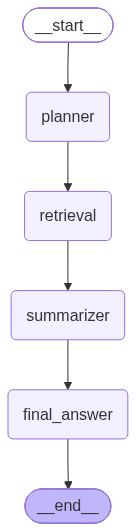

In [12]:
from IPython.display import Image, display

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [13]:
result = app.invoke({
    "question": "What are the benefits of LangGraph?",
    "plan": "",
    "research": "",
    "summary": "",
    "final_answer": ""
})

result

🧠 Planner Agent
Question: What are the benefits of LangGraph?
🔎 Retrieval Agent
📝 Summarizer Agent
💬 Final Answer Agent


{'question': 'What are the benefits of LangGraph?',
 'plan': '1. Understand the question\n2. Gather relevant information\n3. Summarize the findings\n4. Generate a final answer',
 'research': 'Research findings related to: What are the benefits of LangGraph?\n\nLangGraph is a framework for building stateful, multi-step workflows.\nIt supports nodes, edges, conditional routing, parallel execution and state management.',
 'summary': 'LangGraph helps developers build structured, stateful AI workflows. It supports multiple steps, routing, parallel execution and shared state.',
 'final_answer': 'Question: What are the benefits of LangGraph?\n\nAnswer:\nLangGraph helps developers build structured, stateful AI workflows. It supports multiple steps, routing, parallel execution and shared state.'}